In [2]:
%pip install -q transformers

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# IMPORTS + REPRODUCIBILITY
# ============================================================

import os
import json
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    multilabel_confusion_matrix
)

import transformers
from transformers import (
    AutoTokenizer,
    AutoModel
)


# ------------------------------------------------------------
# Fixed random seed
# ------------------------------------------------------------

SEED = 42


def set_seed(seed=SEED):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Transformers: 5.17.0
Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# TARGET TECHNIQUES — SEMEVAL TASK 1 / TASK 2
# ============================================================

TECHNIQUES = [

    "Appeal to authority",

    "Appeal to fear/prejudice",

    "Black-and-white Fallacy/Dictatorship",

    "Causal Oversimplification",

    "Doubt",

    "Exaggeration/Minimisation",

    "Flag-waving",

    "Glittering generalities (Virtue)",

    "Loaded Language",

    "Misrepresentation of Someone's Position (Straw Man)",

    "Name calling/Labeling",

    "Obfuscation, Intentional vagueness, Confusion",

    "Presenting Irrelevant Data (Red Herring)",

    "Reductio ad hitlerum",

    "Repetition",

    "Slogans",

    "Smears",

    "Thought-terminating cliché",

    "Whataboutism",

    "Bandwagon"
]


NUM_LABELS = len(TECHNIQUES)


TECHNIQUE_TO_ID = {
    technique: i
    for i, technique in enumerate(TECHNIQUES)
}


ID_TO_TECHNIQUE = {
    i: technique
    for i, technique in enumerate(TECHNIQUES)
}


print(
    f"Number of target techniques: {NUM_LABELS}"
)

for i, technique in enumerate(TECHNIQUES):

    print(
        f"{i:02d}: {technique}"
    )

Number of target techniques: 20
00: Appeal to authority
01: Appeal to fear/prejudice
02: Black-and-white Fallacy/Dictatorship
03: Causal Oversimplification
04: Doubt
05: Exaggeration/Minimisation
06: Flag-waving
07: Glittering generalities (Virtue)
08: Loaded Language
09: Misrepresentation of Someone's Position (Straw Man)
10: Name calling/Labeling
11: Obfuscation, Intentional vagueness, Confusion
12: Presenting Irrelevant Data (Red Herring)
13: Reductio ad hitlerum
14: Repetition
15: Slogans
16: Smears
17: Thought-terminating cliché
18: Whataboutism
19: Bandwagon


In [5]:
# ============================================================
# DATASET PATHS
# ============================================================

DATA_DIR = Path("data_2026_A2/data")


TRAIN_PATH = (
    DATA_DIR /
    "training_set_task1.txt"
)

DEV_PATH = (
    DATA_DIR /
    "dev_set_task1.txt"
)

TEST_PATH = (
    DATA_DIR /
    "test_set_task1.txt"
)


print("Training:", TRAIN_PATH)
print("Validation:", DEV_PATH)
print("Test:", TEST_PATH)


assert TRAIN_PATH.exists(), (
    f"Training file not found: {TRAIN_PATH}"
)

assert DEV_PATH.exists(), (
    f"Validation file not found: {DEV_PATH}"
)

assert TEST_PATH.exists(), (
    f"Test file not found: {TEST_PATH}"
)

Training: data_2026_A2/data/training_set_task1.txt
Validation: data_2026_A2/data/dev_set_task1.txt
Test: data_2026_A2/data/test_set_task1.txt


In [6]:
# ============================================================
# LOAD DATA
# ============================================================

def load_json_records(path):

    path = Path(path)

    raw_text = path.read_text(
        encoding="utf-8"
    ).strip()

    # Try normal JSON first
    try:

        data = json.loads(raw_text)

        if isinstance(data, dict):

            return [data]

        return data

    except json.JSONDecodeError:

        # Fall back to JSON-lines format
        records = []

        for line in raw_text.splitlines():

            line = line.strip()

            if line:

                records.append(
                    json.loads(line)
                )

        return records


train_records = load_json_records(
    TRAIN_PATH
)

dev_records = load_json_records(
    DEV_PATH
)

test_records = load_json_records(
    TEST_PATH
)


print(
    "Train:",
    len(train_records)
)

print(
    "Validation:",
    len(dev_records)
)

print(
    "Test:",
    len(test_records)
)

Train: 688
Validation: 63
Test: 200


In [7]:
# ============================================================
# DATA VALIDATION + MULTI-HOT LABEL ENCODING
# ============================================================

def encode_labels(labels):

    vector = np.zeros(
        NUM_LABELS,
        dtype=np.float32
    )

    for label in labels:

        if label not in TECHNIQUE_TO_ID:

            raise ValueError(
                f"Unknown technique: {label}"
            )

        vector[
            TECHNIQUE_TO_ID[label]
        ] = 1.0

    return vector


def records_to_dataframe(records):

    rows = []

    for record in records:

        labels = record.get(
            "labels",
            []
        )

        text = record.get(
            "text",
            ""
        )

        rows.append(
            {
                "id": str(
                    record["id"]
                ),

                "text": str(
                    text
                ),

                "labels": labels,

                "target": encode_labels(
                    labels
                )
            }
        )

    return pd.DataFrame(rows)


train_df = records_to_dataframe(
    train_records
)

dev_df = records_to_dataframe(
    dev_records
)

test_df = records_to_dataframe(
    test_records
)


print(
    "Train shape:",
    train_df.shape
)

print(
    "Validation shape:",
    dev_df.shape
)

print(
    "Test shape:",
    test_df.shape
)


print(
    "\nExample:"
)

print(
    train_df.iloc[0][
        ["id", "labels", "text"]
    ]
)

Train shape: (688, 4)
Validation shape: (63, 4)
Test shape: (200, 4)

Example:
id                                                    128
labels             [Black-and-white Fallacy/Dictatorship]
text      THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n
Name: 0, dtype: object


## Part A methodology - multi-label text classification

Part A is a multi-label classification problem because one meme can contain multiple persuasion techniques and can also contain none of the target techniques. Therefore, the model produces 20 independent outputs rather than selecting one mutually exclusive class.

The target labels are represented as a 20-dimensional multi-hot vector. A sigmoid is applied independently to each output to obtain the probability of each technique. `BCEWithLogitsLoss` is used because it directly supports independent binary decisions for multiple labels.

The official SemEval evaluation metric is micro-F1, so validation micro-F1 is the primary criterion for model selection. Macro-F1 is also reported because it gives equal importance to rare and frequent techniques and therefore helps expose poor performance on minority labels.

The held-out test set is not used for architecture selection, hyperparameter tuning or threshold selection.

In [8]:
# ============================================================
# TOKENIZER
# ============================================================

MODEL_NAME = (
    "distilbert/distilroberta-base"
)

MAX_LENGTH = 256


tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


print(
    "Model:",
    MODEL_NAME
)

print(
    "Maximum sequence length:",
    MAX_LENGTH
)

Model: distilbert/distilroberta-base
Maximum sequence length: 256


In [9]:
# ============================================================
# PYTORCH DATASET
# ============================================================

class MemeDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.texts = (
            dataframe[
                "text"
            ].tolist()
        )

        self.targets = np.stack(
            dataframe[
                "target"
            ].values
        )


    def __len__(self):

        return len(
            self.texts
        )


    def __getitem__(
        self,
        index
    ):

        return (
            self.texts[index],
            self.targets[index]
        )


def collate_batch(batch):

    texts = [
        item[0]
        for item in batch
    ]

    targets = np.stack(
        [
            item[1]
            for item in batch
        ]
    )


    encoded = tokenizer(
        texts,

        padding=True,

        truncation=True,

        max_length=MAX_LENGTH,

        return_tensors="pt"
    )


    encoded[
        "labels"
    ] = torch.tensor(
        targets,
        dtype=torch.float32
    )


    return encoded

In [10]:
# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 16


def make_loader(
    dataframe,
    shuffle=False,
    seed=SEED
):

    generator = (
        torch.Generator()
        .manual_seed(seed)
    )

    dataset = MemeDataset(
        dataframe
    )

    return DataLoader(
        dataset,

        batch_size=BATCH_SIZE,

        shuffle=shuffle,

        generator=generator,

        num_workers=0,

        pin_memory=torch.cuda.is_available(),

        collate_fn=collate_batch
    )


train_loader = make_loader(
    train_df,
    shuffle=True,
    seed=SEED
)

dev_loader = make_loader(
    dev_df,
    shuffle=False
)

test_loader = make_loader(
    test_df,
    shuffle=False
)

In [11]:
# ============================================================
# SELF-BUILT MULTI-LABEL CLASSIFIER
# ============================================================

class DistilRoBERTaMultiLabel(
    nn.Module
):

    def __init__(
        self,
        dropout=0.30
    ):

        super().__init__()


        # Pretrained general-purpose encoder
        self.encoder = AutoModel.from_pretrained(
            MODEL_NAME
        )


        hidden_size = (
            self.encoder.config.hidden_size
        )


        # ----------------------------------------------------
        # SELF-BUILT CLASSIFICATION HEAD
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.LayerNorm(
                hidden_size
            ),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_size,
                hidden_size // 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_size // 2,
                NUM_LABELS
            )
        )


    def mean_pool(
        self,
        hidden_states,
        attention_mask
    ):

        mask = (
            attention_mask
            .unsqueeze(-1)
            .float()
        )


        masked_hidden = (
            hidden_states
            * mask
        )


        summed = (
            masked_hidden.sum(
                dim=1
            )
        )


        counts = (
            mask.sum(
                dim=1
            )
            .clamp(
                min=1e-9
            )
        )


        return summed / counts


    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        pooled = self.mean_pool(
            outputs.last_hidden_state,
            attention_mask
        )


        logits = self.classifier(
            pooled
        )


        return logits

In [12]:
# ============================================================
# FREEZE / UNFREEZE
# ============================================================

def freeze_encoder(model):

    for parameter in (
        model.encoder.parameters()
    ):

        parameter.requires_grad = False


    model.encoder_trainable = False


def unfreeze_encoder(model):

    for parameter in (
        model.encoder.parameters()
    ):

        parameter.requires_grad = True


    model.encoder_trainable = True


def count_parameters(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable

In [13]:
# ============================================================
# MULTI-LABEL METRICS
# ============================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold=0.50
):

    y_pred = (
        probabilities >= threshold
    ).astype(int)


    metrics = {

        "micro_f1":
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "micro_precision":
            precision_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),

        "micro_recall":
            recall_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            )
    }


    return metrics


def collect_predictions(
    model,
    loader
):

    model.eval()

    all_probabilities = []
    all_targets = []


    with torch.no_grad():

        for batch in loader:

            labels = batch.pop(
                "labels"
            )

            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }


            logits = model(
                **batch
            )


            probabilities = (
                torch.sigmoid(
                    logits
                )
                .cpu()
                .numpy()
            )


            all_probabilities.append(
                probabilities
            )

            all_targets.append(
                labels.numpy()
            )


    return (
        np.vstack(
            all_targets
        ),

        np.vstack(
            all_probabilities
        )
    )

In [14]:
# ============================================================
# TRAINING
# ============================================================

def run_train_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()


    # Keep a genuinely frozen encoder
    # in evaluation mode.
    if not model.encoder_trainable:

        model.encoder.eval()


    total_loss = 0.0
    total_samples = 0


    for batch in loader:

        labels = batch.pop(
            "labels"
        ).to(device)


        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            **batch
        )


        loss = criterion(
            logits,
            labels
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        optimizer.step()


        batch_size = (
            labels.size(0)
        )


        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += (
            batch_size
        )


    return (
        total_loss
        / total_samples
    )


def evaluate_model(
    model,
    loader,
    criterion,
    threshold=0.50
):

    model.eval()


    total_loss = 0.0
    total_samples = 0


    all_targets = []
    all_probabilities = []


    with torch.no_grad():

        for batch in loader:

            labels = batch.pop(
                "labels"
            ).to(device)


            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }


            logits = model(
                **batch
            )


            loss = criterion(
                logits,
                labels
            )


            probabilities = (
                torch.sigmoid(
                    logits
                )
                .cpu()
                .numpy()
            )


            batch_size = (
                labels.size(0)
            )


            total_loss += (
                loss.item()
                * batch_size
            )

            total_samples += (
                batch_size
            )


            all_targets.append(
                labels.cpu().numpy()
            )

            all_probabilities.append(
                probabilities
            )


    y_true = np.vstack(
        all_targets
    )

    probabilities = np.vstack(
        all_probabilities
    )


    metrics = calculate_metrics(
        y_true,
        probabilities,
        threshold
    )


    metrics["loss"] = (
        total_loss
        / total_samples
    )


    return (
        metrics,
        y_true,
        probabilities
    )


def train_model(
    model,
    optimizer,
    criterion,
    train_loader,
    dev_loader,
    max_epochs=10,
    patience=3,
    threshold=0.50,
    run_name="Experiment"
):

    history = {

        "train_loss": [],

        "val_loss": [],

        "train_micro_f1": [],

        "val_micro_f1": [],

        "train_macro_f1": [],

        "val_macro_f1": []
    }


    best_metric = -np.inf
    best_epoch = 0
    best_state = None
    patience_counter = 0


    print(
        "=" * 72
    )

    print(
        run_name
    )

    print(
        "=" * 72
    )


    for epoch in range(
        1,
        max_epochs + 1
    ):


        train_loss = run_train_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )


        train_metrics, _, _ = (
            evaluate_model(
                model,
                train_loader,
                criterion,
                threshold
            )
        )


        val_metrics, _, _ = (
            evaluate_model(
                model,
                dev_loader,
                criterion,
                threshold
            )
        )


        history[
            "train_loss"
        ].append(
            train_loss
        )

        history[
            "val_loss"
        ].append(
            val_metrics["loss"]
        )

        history[
            "train_micro_f1"
        ].append(
            train_metrics["micro_f1"]
        )

        history[
            "val_micro_f1"
        ].append(
            val_metrics["micro_f1"]
        )

        history[
            "train_macro_f1"
        ].append(
            train_metrics["macro_f1"]
        )

        history[
            "val_macro_f1"
        ].append(
            val_metrics["macro_f1"]
        )


        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Micro F1: "
            f"{train_metrics['micro_f1']:.4f} | "
            f"Train Macro F1: "
            f"{train_metrics['macro_f1']:.4f} | "
            f"Val Loss: "
            f"{val_metrics['loss']:.4f} | "
            f"Val Micro F1: "
            f"{val_metrics['micro_f1']:.4f} | "
            f"Val Macro F1: "
            f"{val_metrics['macro_f1']:.4f}"
        )


        current_metric = (
            val_metrics["micro_f1"]
        )


        if (
            current_metric
            >
            best_metric
        ):

            best_metric = (
                current_metric
            )

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1


        if (
            patience_counter
            >= patience
        ):

            print(
                f"Early stopping after "
                f"{epoch} epochs."
            )

            break


    model.load_state_dict(
        best_state
    )


    best_summary = {

        "best_epoch":
            best_epoch,

        "val_micro_f1":
            best_metric,

        "val_macro_f1":
            history[
                "val_macro_f1"
            ][
                best_epoch - 1
            ],

        "train_micro_f1":
            history[
                "train_micro_f1"
            ][
                best_epoch - 1
            ],

        "train_macro_f1":
            history[
                "train_macro_f1"
            ][
                best_epoch - 1
            ]
    }


    return (
        model,
        history,
        best_summary
    )

In [15]:
# ============================================================
# BASELINE — STAGE 1
# FROZEN PRETRAINED ENCODER + TRAINED HEAD
# ============================================================

set_seed()


baseline_dropout = 0.30
baseline_head_lr = 1e-3
baseline_weight_decay = 0.0


baseline_stage1 = (
    DistilRoBERTaMultiLabel(
        dropout=baseline_dropout
    )
    .to(device)
)


freeze_encoder(
    baseline_stage1
)


criterion = nn.BCEWithLogitsLoss()


optimizer_stage1 = optim.AdamW(
    filter(
        lambda p:
            p.requires_grad,
        baseline_stage1.parameters()
    ),

    lr=baseline_head_lr,

    weight_decay=baseline_weight_decay
)


total_params, trainable_params = (
    count_parameters(
        baseline_stage1
    )
)


print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)


(
    baseline_stage1,
    baseline_stage1_history,
    baseline_stage1_best
) = train_model(

    model=baseline_stage1,

    optimizer=optimizer_stage1,

    criterion=criterion,

    train_loader=train_loader,

    dev_loader=dev_loader,

    max_epochs=10,

    patience=3,

    threshold=0.50,

    run_name=(
        "BASELINE — "
        "Stage 1: Frozen Encoder"
    )
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 82,422,932
Trainable parameters: 304,532
BASELINE — Stage 1: Frozen Encoder
Epoch 01/10 | Train Loss: 0.2885 | Train Micro F1: 0.3831 | Train Macro F1: 0.0343 | Val Loss: 0.2428 | Val Micro F1: 0.3351 | Val Macro F1: 0.0333
Epoch 02/10 | Train Loss: 0.2189 | Train Micro F1: 0.3448 | Train Macro F1: 0.0380 | Val Loss: 0.2294 | Val Micro F1: 0.3210 | Val Macro F1: 0.0371
Epoch 03/10 | Train Loss: 0.2039 | Train Micro F1: 0.3866 | Train Macro F1: 0.0560 | Val Loss: 0.2197 | Val Micro F1: 0.3743 | Val Macro F1: 0.0574
Epoch 04/10 | Train Loss: 0.1952 | Train Micro F1: 0.4376 | Train Macro F1: 0.0711 | Val Loss: 0.2164 | Val Micro F1: 0.4091 | Val Macro F1: 0.0688
Epoch 05/10 | Train Loss: 0.1899 | Train Micro F1: 0.5060 | Train Macro F1: 0.0832 | Val Loss: 0.2133 | Val Micro F1: 0.4688 | Val Macro F1: 0.0818
Epoch 06/10 | Train Loss: 0.1816 | Train Micro F1: 0.5287 | Train Macro F1: 0.0977 | Val Loss: 0.2138 | Val Micro F1: 0.4468 | Val Macro F1: 0.0816
Epoch 07/10 | Trai

In [16]:
# ============================================================
# BASELINE — STAGE 2
# UNFREEZE ENCODER + LOWER LEARNING RATE
# ============================================================

set_seed()


baseline_stage2 = copy.deepcopy(
    baseline_stage1
)


unfreeze_encoder(
    baseline_stage2
)


encoder_lr = 2e-5
head_lr = 1e-3


optimizer_stage2 = optim.AdamW(

    [
        {
            "params":
                baseline_stage2.encoder.parameters(),

            "lr":
                encoder_lr
        },

        {
            "params":
                baseline_stage2.classifier.parameters(),

            "lr":
                head_lr
        }
    ],

    weight_decay=0.0
)


(
    baseline_stage2,
    baseline_stage2_history,
    baseline_stage2_best
) = train_model(

    model=baseline_stage2,

    optimizer=optimizer_stage2,

    criterion=criterion,

    train_loader=train_loader,

    dev_loader=dev_loader,

    max_epochs=8,

    patience=3,

    threshold=0.50,

    run_name=(
        "BASELINE — "
        "Stage 2: Fine-Tuning"
    )
)

BASELINE — Stage 2: Fine-Tuning
Epoch 01/8 | Train Loss: 0.1696 | Train Micro F1: 0.6196 | Train Macro F1: 0.2626 | Val Loss: 0.2284 | Val Micro F1: 0.4181 | Val Macro F1: 0.1222
Epoch 02/8 | Train Loss: 0.1407 | Train Micro F1: 0.7806 | Train Macro F1: 0.4785 | Val Loss: 0.2261 | Val Micro F1: 0.4975 | Val Macro F1: 0.2153
Epoch 03/8 | Train Loss: 0.1183 | Train Micro F1: 0.8363 | Train Macro F1: 0.5510 | Val Loss: 0.2494 | Val Micro F1: 0.5182 | Val Macro F1: 0.1538
Epoch 04/8 | Train Loss: 0.0936 | Train Micro F1: 0.8984 | Train Macro F1: 0.7030 | Val Loss: 0.2547 | Val Micro F1: 0.5540 | Val Macro F1: 0.2680
Epoch 05/8 | Train Loss: 0.0720 | Train Micro F1: 0.9476 | Train Macro F1: 0.7846 | Val Loss: 0.3012 | Val Micro F1: 0.4766 | Val Macro F1: 0.1736
Epoch 06/8 | Train Loss: 0.0559 | Train Micro F1: 0.9751 | Train Macro F1: 0.9344 | Val Loss: 0.3078 | Val Micro F1: 0.5639 | Val Macro F1: 0.3084
Epoch 07/8 | Train Loss: 0.0440 | Train Micro F1: 0.9731 | Train Macro F1: 0.9367 | Va

In [17]:
# ============================================================
# BASELINE COMPARISON
# ============================================================

baseline_comparison = pd.DataFrame(
    [

        {
            "Stage":
                "Stage 1 — Frozen Encoder",

            "Best Epoch":
                baseline_stage1_best[
                    "best_epoch"
                ],

            "Train Micro F1":
                baseline_stage1_best[
                    "train_micro_f1"
                ],

            "Validation Micro F1":
                baseline_stage1_best[
                    "val_micro_f1"
                ],

            "Train Macro F1":
                baseline_stage1_best[
                    "train_macro_f1"
                ],

            "Validation Macro F1":
                baseline_stage1_best[
                    "val_macro_f1"
                ]
        },


        {
            "Stage":
                "Stage 2 — Fine-Tuning",

            "Best Epoch":
                baseline_stage2_best[
                    "best_epoch"
                ],

            "Train Micro F1":
                baseline_stage2_best[
                    "train_micro_f1"
                ],

            "Validation Micro F1":
                baseline_stage2_best[
                    "val_micro_f1"
                ],

            "Train Macro F1":
                baseline_stage2_best[
                    "train_macro_f1"
                ],

            "Validation Macro F1":
                baseline_stage2_best[
                    "val_macro_f1"
                ]
        }
    ]
)


display(
    baseline_comparison.round(4)
)


if (
    baseline_stage2_best[
        "val_micro_f1"
    ]
    >
    baseline_stage1_best[
        "val_micro_f1"
    ]
):

    SELECTED_STAGE = "Stage 2"

    selected_stage1_state = (
        baseline_stage1.state_dict()
    )

    print(
        "Selected architecture: "
        "Stage 2 — Fine-Tuning"
    )

else:

    SELECTED_STAGE = "Stage 1"

    print(
        "Selected architecture: "
        "Stage 1 — Frozen Encoder"
    )

,Stage,Best Epoch,Train Micro F1,Validation Micro F1,Train Macro F1,Validation Macro F1
0,Stage 1 — Frozen Encoder,10,0.5982,0.4949,0.1615,0.1147
1,Stage 2 — Fine-Tuning,6,0.9751,0.5639,0.9344,0.3084


Selected architecture: Stage 2 — Fine-Tuning


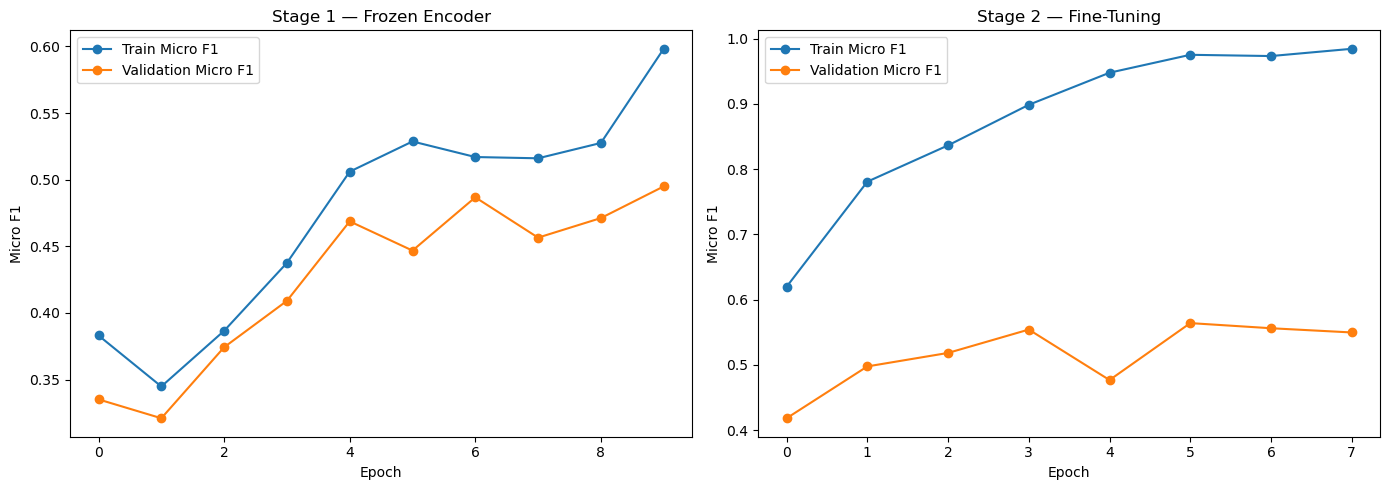

In [18]:
# ============================================================
# BASELINE LEARNING CURVES
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# Stage 1
# ------------------------------------------------------------

axes[0].plot(
    baseline_stage1_history[
        "train_micro_f1"
    ],
    marker="o",
    label="Train Micro F1"
)

axes[0].plot(
    baseline_stage1_history[
        "val_micro_f1"
    ],
    marker="o",
    label="Validation Micro F1"
)

axes[0].set_title(
    "Stage 1 — Frozen Encoder"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Micro F1"
)

axes[0].legend()


# ------------------------------------------------------------
# Stage 2
# ------------------------------------------------------------

axes[1].plot(
    baseline_stage2_history[
        "train_micro_f1"
    ],
    marker="o",
    label="Train Micro F1"
)

axes[1].plot(
    baseline_stage2_history[
        "val_micro_f1"
    ],
    marker="o",
    label="Validation Micro F1"
)

axes[1].set_title(
    "Stage 2 — Fine-Tuning"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "Micro F1"
)

axes[1].legend()


plt.tight_layout()
plt.show()

## Stage 2 decision

Stage 2 is included as a controlled transfer-learning experiment rather than being assumed to be beneficial. It starts from the same Stage 1 model and unfreezes the pretrained encoder using a substantially smaller learning rate.

This is important because the labelled meme corpus is small. Fine-tuning the encoder exposes substantially more parameters to the task-specific data, which may improve adaptation but can also increase overfitting.

The later experiments therefore retain the stage that achieves the stronger validation micro-F1. If Stage 2 does not improve validation performance, subsequent tuning uses the simpler frozen-encoder model. This keeps the final system smaller in terms of trainable parameters and avoids unnecessary adaptation of the pretrained representation.

In [19]:
# ============================================================
# HYPERPARAMETER TUNING CONFIGURATION
# ============================================================

DROPOUT_GRID = [
    0.10,
    0.30,
    0.50
]


if SELECTED_STAGE == "Stage 1":

    LR_GRID = [
        5e-4,
        1e-3,
        2e-3
    ]

else:

    LR_GRID = [
        1e-5,
        2e-5,
        5e-5
    ]


WEIGHT_DECAY_GRID = [
    0.0,
    1e-4,
    1e-3
]


TUNING_EPOCHS = 8
TUNING_PATIENCE = 2


print(
    "Selected stage:",
    SELECTED_STAGE
)

print(
    "Dropout:",
    DROPOUT_GRID
)

print(
    "Learning rates:",
    LR_GRID
)

print(
    "Weight decay:",
    WEIGHT_DECAY_GRID
)

Selected stage: Stage 2
Dropout: [0.1, 0.3, 0.5]
Learning rates: [1e-05, 2e-05, 5e-05]
Weight decay: [0.0, 0.0001, 0.001]


In [20]:
# ============================================================
# HYPERPARAMETER CANDIDATE TRAINING
# ============================================================

def train_candidate(
    dropout,
    learning_rate,
    weight_decay,
    stage
):

    set_seed()


    model = (
        DistilRoBERTaMultiLabel(
            dropout=dropout
        )
        .to(device)
    )


    if stage == "Stage 1":

        freeze_encoder(
            model
        )


        optimizer = optim.AdamW(

            filter(
                lambda p:
                    p.requires_grad,
                model.parameters()
            ),

            lr=learning_rate,

            weight_decay=weight_decay
        )


    else:

        # Start every Stage 2 candidate
        # from the same Stage 1 baseline.
        model.load_state_dict(
            baseline_stage1.state_dict()
        )


        unfreeze_encoder(
            model
        )


        optimizer = optim.AdamW(

            [
                {
                    "params":
                        model.encoder.parameters(),

                    "lr":
                        learning_rate
                },

                {
                    "params":
                        model.classifier.parameters(),

                    "lr":
                        1e-3
                }
            ],

            weight_decay=weight_decay
        )


    model, history, best = (
        train_model(

            model=model,

            optimizer=optimizer,

            criterion=criterion,

            train_loader=train_loader,

            dev_loader=dev_loader,

            max_epochs=TUNING_EPOCHS,

            patience=TUNING_PATIENCE,

            threshold=0.5,

            run_name=(
                f"TUNING | "
                f"stage={stage} | "
                f"dropout={dropout} | "
                f"lr={learning_rate} | "
                f"wd={weight_decay}"
            )
        )
    )


    return (
        model,
        history,
        best
    )

In [21]:
# ============================================================
# TUNING 1 — DROPOUT
# ============================================================

BASE_LR = (
    1e-3
    if SELECTED_STAGE == "Stage 1"
    else 2e-5
)


dropout_results = {}


for dropout in DROPOUT_GRID:

    model, history, best = (
        train_candidate(

            dropout=dropout,

            learning_rate=BASE_LR,

            weight_decay=0.0,

            stage=SELECTED_STAGE
        )
    )


    dropout_results[
        dropout
    ] = {

        "model":
            model,

        "history":
            history,

        "best":
            best
    }


dropout_summary = pd.DataFrame(

    [

        {
            "Dropout":
                dropout,

            "Best Epoch":
                result[
                    "best"
                ][
                    "best_epoch"
                ],

            "Validation Micro F1":
                result[
                    "best"
                ][
                    "val_micro_f1"
                ],

            "Validation Macro F1":
                result[
                    "best"
                ][
                    "val_macro_f1"
                ]
        }

        for dropout, result
        in dropout_results.items()
    ]
)


display(
    dropout_summary.round(4)
)


BEST_DROPOUT = float(
    dropout_summary.loc[
        dropout_summary[
            "Validation Micro F1"
        ].idxmax()
    ][
        "Dropout"
    ]
)


print(
    "Selected dropout:",
    BEST_DROPOUT
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TUNING | stage=Stage 2 | dropout=0.1 | lr=2e-05 | wd=0.0
Epoch 01/8 | Train Loss: 0.1600 | Train Micro F1: 0.7120 | Train Macro F1: 0.3200 | Val Loss: 0.2116 | Val Micro F1: 0.5025 | Val Macro F1: 0.1454
Epoch 02/8 | Train Loss: 0.1232 | Train Micro F1: 0.7809 | Train Macro F1: 0.5393 | Val Loss: 0.2271 | Val Micro F1: 0.4747 | Val Macro F1: 0.1873
Epoch 03/8 | Train Loss: 0.0936 | Train Micro F1: 0.8955 | Train Macro F1: 0.6504 | Val Loss: 0.2610 | Val Micro F1: 0.5068 | Val Macro F1: 0.1941
Epoch 04/8 | Train Loss: 0.0673 | Train Micro F1: 0.9219 | Train Macro F1: 0.7448 | Val Loss: 0.3181 | Val Micro F1: 0.4729 | Val Macro F1: 0.1573
Epoch 05/8 | Train Loss: 0.0472 | Train Micro F1: 0.9579 | Train Macro F1: 0.9361 | Val Loss: 0.3704 | Val Micro F1: 0.5422 | Val Macro F1: 0.2854
Epoch 06/8 | Train Loss: 0.0367 | Train Micro F1: 0.9818 | Train Macro F1: 0.9817 | Val Loss: 0.3868 | Val Micro F1: 0.4789 | Val Macro F1: 0.2629
Epoch 07/8 | Train Loss: 0.0279 | Train Micro F1: 0.9924 | Tr

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TUNING | stage=Stage 2 | dropout=0.5 | lr=2e-05 | wd=0.0
Epoch 01/8 | Train Loss: 0.1780 | Train Micro F1: 0.3654 | Train Macro F1: 0.1629 | Val Loss: 0.2362 | Val Micro F1: 0.3046 | Val Macro F1: 0.0937
Epoch 02/8 | Train Loss: 0.1616 | Train Micro F1: 0.7199 | Train Macro F1: 0.3968 | Val Loss: 0.2147 | Val Micro F1: 0.4951 | Val Macro F1: 0.1507
Epoch 03/8 | Train Loss: 0.1382 | Train Micro F1: 0.7951 | Train Macro F1: 0.4966 | Val Loss: 0.2097 | Val Micro F1: 0.5472 | Val Macro F1: 0.1855
Epoch 04/8 | Train Loss: 0.1167 | Train Micro F1: 0.8336 | Train Macro F1: 0.5593 | Val Loss: 0.2359 | Val Micro F1: 0.4902 | Val Macro F1: 0.2072
Epoch 05/8 | Train Loss: 0.1032 | Train Micro F1: 0.8688 | Train Macro F1: 0.6314 | Val Loss: 0.2396 | Val Micro F1: 0.5243 | Val Macro F1: 0.2404
Early stopping after 5 epochs.


,Dropout,Best Epoch,Validation Micro F1,Validation Macro F1
0,0.1,5,0.5422,0.2854
1,0.3,1,0.5413,0.1622
2,0.5,3,0.5472,0.1855


Selected dropout: 0.5


In [22]:
# ============================================================
# TUNING 2 — LEARNING RATE
# ============================================================

lr_results = {}


for learning_rate in LR_GRID:

    model, history, best = (
        train_candidate(

            dropout=BEST_DROPOUT,

            learning_rate=learning_rate,

            weight_decay=0.0,

            stage=SELECTED_STAGE
        )
    )


    lr_results[
        learning_rate
    ] = {

        "model":
            model,

        "history":
            history,

        "best":
            best
    }


lr_summary = pd.DataFrame(

    [

        {
            "Learning Rate":
                lr,

            "Best Epoch":
                result[
                    "best"
                ][
                    "best_epoch"
                ],

            "Validation Micro F1":
                result[
                    "best"
                ][
                    "val_micro_f1"
                ],

            "Validation Macro F1":
                result[
                    "best"
                ][
                    "val_macro_f1"
                ]
        }

        for lr, result
        in lr_results.items()
    ]
)


display(
    lr_summary.round(4)
)


BEST_LR = float(
    lr_summary.loc[
        lr_summary[
            "Validation Micro F1"
        ].idxmax()
    ][
        "Learning Rate"
    ]
)


print(
    "Selected learning rate:",
    BEST_LR
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TUNING | stage=Stage 2 | dropout=0.5 | lr=1e-05 | wd=0.0
Epoch 01/8 | Train Loss: 0.1740 | Train Micro F1: 0.5982 | Train Macro F1: 0.2688 | Val Loss: 0.2158 | Val Micro F1: 0.4457 | Val Macro F1: 0.1348
Epoch 02/8 | Train Loss: 0.1561 | Train Micro F1: 0.6982 | Train Macro F1: 0.3521 | Val Loss: 0.2158 | Val Micro F1: 0.5392 | Val Macro F1: 0.1636
Epoch 03/8 | Train Loss: 0.1440 | Train Micro F1: 0.7265 | Train Macro F1: 0.3787 | Val Loss: 0.2207 | Val Micro F1: 0.5025 | Val Macro F1: 0.1774
Epoch 04/8 | Train Loss: 0.1315 | Train Micro F1: 0.7723 | Train Macro F1: 0.4349 | Val Loss: 0.2326 | Val Micro F1: 0.5174 | Val Macro F1: 0.2117
Early stopping after 4 epochs.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TUNING | stage=Stage 2 | dropout=0.5 | lr=5e-05 | wd=0.0
Epoch 01/8 | Train Loss: 0.1970 | Train Micro F1: 0.6575 | Train Macro F1: 0.2867 | Val Loss: 0.2145 | Val Micro F1: 0.4873 | Val Macro F1: 0.1365
Epoch 02/8 | Train Loss: 0.1541 | Train Micro F1: 0.7510 | Train Macro F1: 0.4345 | Val Loss: 0.2245 | Val Micro F1: 0.5278 | Val Macro F1: 0.1770
Epoch 03/8 | Train Loss: 0.1333 | Train Micro F1: 0.7548 | Train Macro F1: 0.4503 | Val Loss: 0.2458 | Val Micro F1: 0.4309 | Val Macro F1: 0.1004
Epoch 04/8 | Train Loss: 0.1122 | Train Micro F1: 0.8651 | Train Macro F1: 0.5547 | Val Loss: 0.2523 | Val Micro F1: 0.5217 | Val Macro F1: 0.1553
Early stopping after 4 epochs.


,Learning Rate,Best Epoch,Validation Micro F1,Validation Macro F1
0,0.0,2,0.5392,0.1636
1,0.0,4,0.5140,0.1384
2,0.0,2,0.5278,0.1770


Selected learning rate: 1e-05


In [23]:
# ============================================================
# TUNING 3 — WEIGHT DECAY
# ============================================================

wd_results = {}


for weight_decay in (
    WEIGHT_DECAY_GRID
):

    model, history, best = (
        train_candidate(

            dropout=BEST_DROPOUT,

            learning_rate=BEST_LR,

            weight_decay=weight_decay,

            stage=SELECTED_STAGE
        )
    )


    wd_results[
        weight_decay
    ] = {

        "model":
            model,

        "history":
            history,

        "best":
            best
    }


wd_summary = pd.DataFrame(

    [

        {
            "Weight Decay":
                wd,

            "Best Epoch":
                result[
                    "best"
                ][
                    "best_epoch"
                ],

            "Validation Micro F1":
                result[
                    "best"
                ][
                    "val_micro_f1"
                ],

            "Validation Macro F1":
                result[
                    "best"
                ][
                    "val_macro_f1"
                ]
        }

        for wd, result
        in wd_results.items()
    ]
)


display(
    wd_summary.round(4)
)


BEST_WD = float(
    wd_summary.loc[
        wd_summary[
            "Validation Micro F1"
        ].idxmax()
    ][
        "Weight Decay"
    ]
)


print(
    "Selected weight decay:",
    BEST_WD
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TUNING | stage=Stage 2 | dropout=0.5 | lr=1e-05 | wd=0.0
Epoch 01/8 | Train Loss: 0.1733 | Train Micro F1: 0.6158 | Train Macro F1: 0.2398 | Val Loss: 0.2145 | Val Micro F1: 0.4607 | Val Macro F1: 0.0995
Epoch 02/8 | Train Loss: 0.1590 | Train Micro F1: 0.7054 | Train Macro F1: 0.3983 | Val Loss: 0.2236 | Val Micro F1: 0.5660 | Val Macro F1: 0.2168
Epoch 03/8 | Train Loss: 0.1410 | Train Micro F1: 0.7256 | Train Macro F1: 0.3889 | Val Loss: 0.2183 | Val Micro F1: 0.5102 | Val Macro F1: 0.1342
Epoch 04/8 | Train Loss: 0.1321 | Train Micro F1: 0.7689 | Train Macro F1: 0.4758 | Val Loss: 0.2198 | Val Micro F1: 0.5403 | Val Macro F1: 0.2211
Early stopping after 4 epochs.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TUNING | stage=Stage 2 | dropout=0.5 | lr=1e-05 | wd=0.001
Epoch 01/8 | Train Loss: 0.1727 | Train Micro F1: 0.5295 | Train Macro F1: 0.2026 | Val Loss: 0.2116 | Val Micro F1: 0.3837 | Val Macro F1: 0.1108
Epoch 02/8 | Train Loss: 0.1566 | Train Micro F1: 0.6913 | Train Macro F1: 0.3157 | Val Loss: 0.2124 | Val Micro F1: 0.5100 | Val Macro F1: 0.1465
Epoch 03/8 | Train Loss: 0.1457 | Train Micro F1: 0.7007 | Train Macro F1: 0.3923 | Val Loss: 0.2134 | Val Micro F1: 0.4574 | Val Macro F1: 0.1750
Epoch 04/8 | Train Loss: 0.1301 | Train Micro F1: 0.7652 | Train Macro F1: 0.5001 | Val Loss: 0.2299 | Val Micro F1: 0.4796 | Val Macro F1: 0.1882
Early stopping after 4 epochs.


,Weight Decay,Best Epoch,Validation Micro F1,Validation Macro F1
0,0.0000,2,0.566,0.2168
1,0.0001,2,0.500,0.1763
2,0.0010,2,0.510,0.1465


Selected weight decay: 0.0


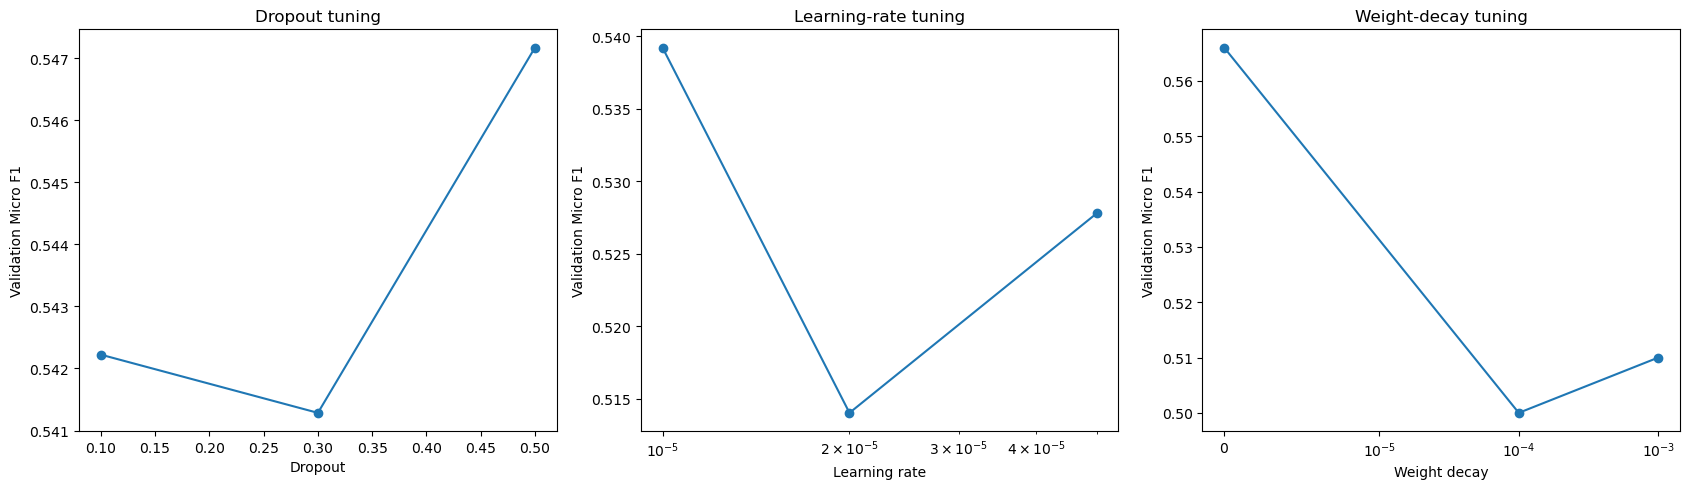

In [24]:
# ============================================================
# HYPERPARAMETER TUNING SUMMARY
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)


axes[0].plot(
    dropout_summary[
        "Dropout"
    ],

    dropout_summary[
        "Validation Micro F1"
    ],

    marker="o"
)

axes[0].set_title(
    "Dropout tuning"
)

axes[0].set_xlabel(
    "Dropout"
)

axes[0].set_ylabel(
    "Validation Micro F1"
)


axes[1].plot(
    lr_summary[
        "Learning Rate"
    ],

    lr_summary[
        "Validation Micro F1"
    ],

    marker="o"
)

axes[1].set_title(
    "Learning-rate tuning"
)

axes[1].set_xlabel(
    "Learning rate"
)

axes[1].set_ylabel(
    "Validation Micro F1"

)

axes[1].set_xscale(
    "log"
)


axes[2].plot(
    wd_summary[
        "Weight Decay"
    ],

    wd_summary[
        "Validation Micro F1"
    ],

    marker="o"
)

axes[2].set_title(
    "Weight-decay tuning"
)

axes[2].set_xlabel(
    "Weight decay"
)

axes[2].set_ylabel(
    "Validation Micro F1"
)

axes[2].set_xscale(
    "symlog",
    linthresh=1e-5
)


plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# THRESHOLD TUNING
# ============================================================

if SELECTED_STAGE == "Stage 1":

    selected_model = baseline_stage1

else:

    selected_model = baseline_stage2


dev_true, dev_probabilities = (
    collect_predictions(
        selected_model,
        dev_loader
    )
)


threshold_values = np.arange(
    0.10,
    0.91,
    0.05
)


threshold_results = []


for threshold in threshold_values:

    metrics = calculate_metrics(
        dev_true,
        dev_probabilities,
        threshold=threshold
    )


    threshold_results.append(
        {
            "Threshold":
                threshold,

            "Micro F1":
                metrics["micro_f1"],

            "Macro F1":
                metrics["macro_f1"],

            "Precision":
                metrics["micro_precision"],

            "Recall":
                metrics["micro_recall"]
        }
    )


threshold_df = pd.DataFrame(
    threshold_results
)


display(
    threshold_df.round(4)
)


best_threshold_row = (
    threshold_df.loc[
        threshold_df[
            "Micro F1"
        ].idxmax()
    ]
)


BEST_THRESHOLD = float(
    best_threshold_row[
        "Threshold"
    ]
)


print(
    f"Selected threshold: "
    f"{BEST_THRESHOLD:.2f}"
)

,Threshold,Micro F1,Macro F1,Precision,Recall
0,0.10,0.5139,0.3192,0.4150,0.6748
1,0.15,0.5306,0.3251,0.4561,0.6341
2,0.20,0.5328,0.2751,0.4834,0.5935
3,0.25,0.5211,0.2773,0.4928,0.5528
4,0.30,0.5255,0.2800,0.5076,0.5447
5,0.35,0.5403,0.2955,0.5360,0.5447
6,0.40,0.5570,0.3033,0.5789,0.5366
7,0.45,0.5603,0.3057,0.5963,0.5285
8,0.50,0.5639,0.3084,0.6154,0.5203
9,0.55,0.5625,0.3097,0.6238,0.5122


Selected threshold: 0.60


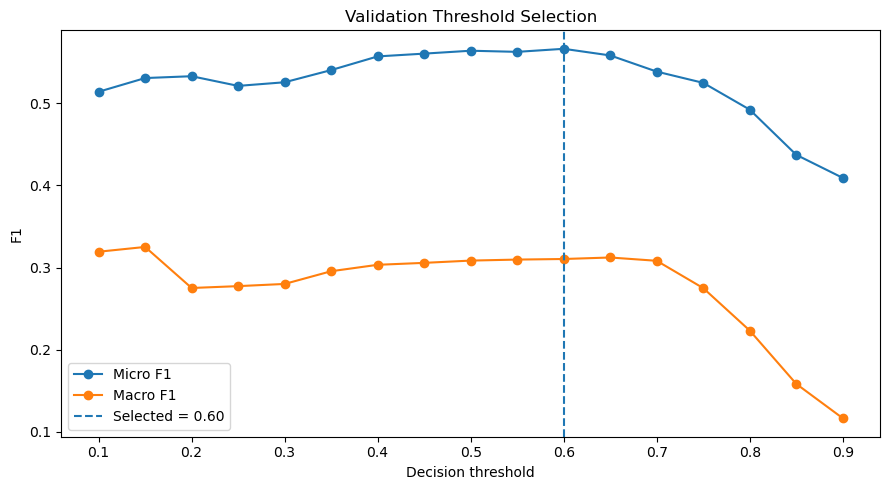

In [26]:
# ============================================================
# THRESHOLD SELECTION FIGURE
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    threshold_df[
        "Threshold"
    ],

    threshold_df[
        "Micro F1"
    ],

    marker="o",

    label="Micro F1"
)


plt.plot(
    threshold_df[
        "Threshold"
    ],

    threshold_df[
        "Macro F1"
    ],

    marker="o",

    label="Macro F1"
)


plt.axvline(
    BEST_THRESHOLD,

    linestyle="--",

    label=(
        f"Selected = "
        f"{BEST_THRESHOLD:.2f}"
    )
)


plt.xlabel(
    "Decision threshold"
)

plt.ylabel(
    "F1"
)

plt.title(
    "Validation Threshold Selection"
)

plt.legend()

plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# FINAL CONFIGURATION
# ============================================================

print(
    "============================================================"
)

print(
    "FINAL SELECTED CONFIGURATION"
)

print(
    "============================================================"
)

print(
    "Encoder:",
    MODEL_NAME
)

print(
    "Stage:",
    SELECTED_STAGE
)

print(
    "Dropout:",
    BEST_DROPOUT
)

print(
    "Learning rate:",
    BEST_LR
)

print(
    "Weight decay:",
    BEST_WD
)

print(
    "Decision threshold:",
    BEST_THRESHOLD
)

FINAL SELECTED CONFIGURATION
Encoder: distilbert/distilroberta-base
Stage: Stage 2
Dropout: 0.5
Learning rate: 1e-05
Weight decay: 0.0
Decision threshold: 0.6000000000000002


In [28]:
# ============================================================
# FINAL VALIDATION RESULT
# ============================================================

final_tuned_model = (
    wd_results[
        BEST_WD
    ][
        "model"
    ]
)


final_val_metrics, _, _ = (
    evaluate_model(

        final_tuned_model,

        dev_loader,

        criterion,

        threshold=BEST_THRESHOLD
    )
)


print(
    "============================================================"
)

print(
    "FINAL VALIDATION PERFORMANCE"
)

print(
    "============================================================"
)

print(
    f"Validation Micro F1: "
    f"{final_val_metrics['micro_f1']:.4f}"
)

print(
    f"Validation Macro F1: "
    f"{final_val_metrics['macro_f1']:.4f}"
)

print(
    f"Validation Precision: "
    f"{final_val_metrics['micro_precision']:.4f}"
)

print(
    f"Validation Recall: "
    f"{final_val_metrics['micro_recall']:.4f}"
)

FINAL VALIDATION PERFORMANCE
Validation Micro F1: 0.4516
Validation Macro F1: 0.1744
Validation Precision: 0.6667
Validation Recall: 0.3415


## Model lock before held-out testing

The validation set has been used for architecture selection, hyperparameter selection and decision-threshold selection. The test set has not been used for any of these decisions.

At this point the configuration is locked. The final model will be retrained using the available training and validation data, using the selected architecture and hyperparameters. The previously selected decision threshold is retained rather than re-optimised using the test set.

This preserves the role of the test set as an independent estimate of performance after model development is complete.

In [29]:
# ============================================================
# FINAL TRAINING DATA
# ============================================================

train_dev_df = pd.concat(
    [
        train_df,
        dev_df
    ],

    ignore_index=True
)


print(
    "Final training samples:",
    len(train_dev_df)
)


train_dev_loader = make_loader(
    train_dev_df,
    shuffle=True,
    seed=SEED
)

Final training samples: 751


In [30]:
# ============================================================
# FIXED-EPOCH TRAINING
# USED ONLY AFTER HYPERPARAMETERS ARE LOCKED
# ============================================================

def fit_fixed_epochs(
    model,
    loader,
    optimizer,
    criterion,
    epochs
):

    model.train()


    for epoch in range(
        1,
        epochs + 1
    ):

        if not model.encoder_trainable:

            model.encoder.eval()


        total_loss = 0.0
        total_samples = 0


        for batch in loader:

            labels = batch.pop(
                "labels"
            ).to(device)


            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(
                **batch
            )


            loss = criterion(
                logits,
                labels
            )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            optimizer.step()


            batch_size = (
                labels.size(0)
            )


            total_loss += (
                loss.item()
                * batch_size
            )

            total_samples += (
                batch_size
            )


        epoch_loss = (
            total_loss
            / total_samples
        )


        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )


    return model

In [31]:
# ============================================================
# FINAL MODEL RETRAINING
# ============================================================

set_seed()


final_model = (
    DistilRoBERTaMultiLabel(
        dropout=BEST_DROPOUT
    )
    .to(device)
)


# ------------------------------------------------------------
# Stage 1
# ------------------------------------------------------------

freeze_encoder(
    final_model
)


final_stage1_epochs = (
    baseline_stage1_best[
        "best_epoch"
    ]
)


final_optimizer_stage1 = (
    optim.AdamW(

        filter(
            lambda p:
                p.requires_grad,

            final_model.parameters()
        ),

        lr=(
            BEST_LR
            if SELECTED_STAGE == "Stage 1"
            else 1e-3
        ),

        weight_decay=BEST_WD
    )
)


print(
    "Final training — Stage 1"
)


final_model = fit_fixed_epochs(

    model=final_model,

    loader=train_dev_loader,

    optimizer=final_optimizer_stage1,

    criterion=criterion,

    epochs=final_stage1_epochs
)


# ------------------------------------------------------------
# Stage 2 if selected
# ------------------------------------------------------------

if SELECTED_STAGE == "Stage 2":

    unfreeze_encoder(
        final_model
    )


    final_stage2_epochs = (
        wd_results[
            BEST_WD
        ][
            "best"
        ][
            "best_epoch"
        ]
    )


    final_optimizer_stage2 = (
        optim.AdamW(

            [
                {
                    "params":
                        final_model.encoder.parameters(),

                    "lr":
                        BEST_LR
                },

                {
                    "params":
                        final_model.classifier.parameters(),

                    "lr":
                        1e-3
                }
            ],

            weight_decay=BEST_WD
        )
    )


    print(
        "\nFinal training — Stage 2"
    )


    final_model = fit_fixed_epochs(

        model=final_model,

        loader=train_dev_loader,

        optimizer=final_optimizer_stage2,

        criterion=criterion,

        epochs=final_stage2_epochs
    )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilbert/distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Final training — Stage 1
Epoch 01/10 | Loss: 0.2970
Epoch 02/10 | Loss: 0.2257
Epoch 03/10 | Loss: 0.2144
Epoch 04/10 | Loss: 0.2067
Epoch 05/10 | Loss: 0.2018
Epoch 06/10 | Loss: 0.1971
Epoch 07/10 | Loss: 0.1918
Epoch 08/10 | Loss: 0.1870
Epoch 09/10 | Loss: 0.1846
Epoch 10/10 | Loss: 0.1822

Final training — Stage 2
Epoch 01/2 | Loss: 0.1829
Epoch 02/2 | Loss: 0.1661
